# Computes Δ pAE_int_peptide (on-target minus off-target) for all 199 designs and visualizes peptide pLDDT distributions.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ON_DIR  = "~/Desktop/pmhc_binder_kras/specificity/pMHC_fold/outputs/r2/pmhc_fold_on_runs"
OFF_DIR = "~/Desktop/pmhc_binder_kras/specificity/pMHC_fold/outputs/r2/pmhc_fold_off_runs"
OUT_DIR = "~/Desktop/pmhc_binder_kras/specificity/pMHC_fold/outputs/r2/analysis"
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
# ── Load all .sc files ────────────────────────────────────────────────────────
def load_sc_files(base_dir, pattern="sample_df_chunk_*/metrics.sc"):
    files = sorted(glob.glob(os.path.join(base_dir, pattern)))
    if not files:
        # try direct .sc files
        files = sorted(glob.glob(os.path.join(base_dir, "**/*.sc"), recursive=True))
    print(f"  Found {len(files)} .sc files in {base_dir}")
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            if len(df) > 0:
                dfs.append(df)
        except Exception as e:
            print(f"  WARNING: could not read {f}: {e}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print("Loading on-target scores...")
on_df = load_sc_files(ON_DIR)
print(f"  {len(on_df)} on-target rows")

print("Loading off-target scores...")
off_df = load_sc_files(OFF_DIR)
print(f"  {len(off_df)} off-target rows")

# ── Extract base design name ──────────────────────────────────────────────────
# on-target  description: orient_XXX_af2pred_A1101_VVGADGVGK
# off-target description: orient_XXX_af2pred_wt_A1101_VVGAGGVGK
def extract_base_name(description):
    """Strip allele/peptide suffix and _wt tag to get the design name."""
    name = description
    # remove allele+peptide suffix
    for suffix in ['_A1101_VVGADGVGK', '_A1101_VVGAGGVGK']:
        name = name.replace(suffix, '')
    # remove _wt tag
    name = name.replace('_wt', '')
    return name

on_df['base_name']  = on_df['description'].apply(extract_base_name)
off_df['base_name'] = off_df['description'].apply(extract_base_name)

# ── Check for duplicates ──────────────────────────────────────────────────────
on_dups  = on_df[on_df.duplicated('base_name', keep=False)]
off_dups = off_df[off_df.duplicated('base_name', keep=False)]
if len(on_dups):
    print(f"WARNING: {len(on_dups)} duplicate base names in on-target — keeping first")
    on_df = on_df.drop_duplicates('base_name', keep='first')
if len(off_dups):
    print(f"WARNING: {len(off_dups)} duplicate base names in off-target — keeping first")
    off_df = off_df.drop_duplicates('base_name', keep='first')

# ── Merge on-target and off-target ────────────────────────────────────────────
merged = on_df.merge(
    off_df,
    on='base_name',
    suffixes=('_on', '_off'),
    how='inner'
)
print(f"\nMerged: {len(merged)} designs with both on- and off-target scores")

missing_on  = set(on_df['base_name'])  - set(off_df['base_name'])
missing_off = set(off_df['base_name']) - set(on_df['base_name'])
if missing_on:
    print(f"  {len(missing_on)} designs in on-target only (no off-target match)")
if missing_off:
    print(f"  {len(missing_off)} designs in off-target only (no on-target match)")

# ── Compute specificity score ─────────────────────────────────────────────────
# Δ pAE_int_peptide = on_target - off_target
# More negative = better specificity for G12D over G12 WT
merged['delta_pae_int_peptide'] = (
    merged['ppi_pae_int_peptide_on'] - merged['ppi_pae_int_peptide_off']
)

# Also compute Δ for the full binder-pMHC interface for reference
merged['delta_pae_int'] = merged['ppi_pae_int_on'] - merged['ppi_pae_int_off']

# ── Summary statistics ────────────────────────────────────────────────────────
print("\n── Specificity score (Δ pAE_int_peptide) ──")
print(f"  Mean:   {merged['delta_pae_int_peptide'].mean():.3f}")
print(f"  Median: {merged['delta_pae_int_peptide'].median():.3f}")
print(f"  Std:    {merged['delta_pae_int_peptide'].std():.3f}")
print(f"  Min:    {merged['delta_pae_int_peptide'].min():.3f}")
print(f"  Max:    {merged['delta_pae_int_peptide'].max():.3f}")
n_specific = (merged['delta_pae_int_peptide'] < 0).sum()
print(f"  Designs with Δ < 0 (specific for G12D): {n_specific}/{len(merged)}")

# ── Top and bottom designs ────────────────────────────────────────────────────
merged_sorted = merged.sort_values('delta_pae_int_peptide')

print("\n── Top 20 most specific designs (most negative Δ pAE_int_peptide) ──")
top20_cols = [
    'base_name',
    'ppi_pae_int_peptide_on', 'ppi_pae_int_peptide_off',
    'delta_pae_int_peptide',
    'plddt_peptide_on', 'plddt_peptide_off',
    'ppi_pae_int_on', 'ppi_pae_int_off'
]
print(merged_sorted[top20_cols].head(20).to_string(index=False))

print("\n── Bottom 10 least specific designs (most positive Δ pAE_int_peptide) ──")
print(merged_sorted[top20_cols].tail(10).to_string(index=False))

# ── Save full results ─────────────────────────────────────────────────────────
out_csv = os.path.join(OUT_DIR, 'pmhc_fold_specificity_scores.tsv')
merged_sorted.to_csv(out_csv, sep='\t', index=False)
print(f"\nFull results saved to {out_csv}")

Loading on-target scores...
  Found 10 .sc files in ~/Desktop/pmhc_binder_kras/specificity/pMHC_fold/outputs/r2/pmhc_fold_on_runs
  199 on-target rows
Loading off-target scores...
  Found 10 .sc files in ~/Desktop/pmhc_binder_kras/specificity/pMHC_fold/outputs/r2/pmhc_fold_off_runs
  199 off-target rows

Merged: 199 designs with both on- and off-target scores

── Specificity score (Δ pAE_int_peptide) ──
  Mean:   1.298
  Median: 0.848
  Std:    2.219
  Min:    -3.982
  Max:    6.462
  Designs with Δ < 0 (specific for G12D): 64/199

── Top 20 most specific designs (most negative Δ pAE_int_peptide) ──
                           base_name  ppi_pae_int_peptide_on  ppi_pae_int_peptide_off  delta_pae_int_peptide  plddt_peptide_on  plddt_peptide_off  ppi_pae_int_on  ppi_pae_int_off
orient_255_pT12__33_sample06_af2pred                  12.639                   16.621                 -3.982            59.896             72.601           6.194           15.091
orient_158_pT12__76_sample04_af2pre

## Visualization

Figure saved to ~/Desktop/pmhc_binder_kras/specificity/pMHC_fold/outputs/r2/analysis/pmhc_fold_specificity.png


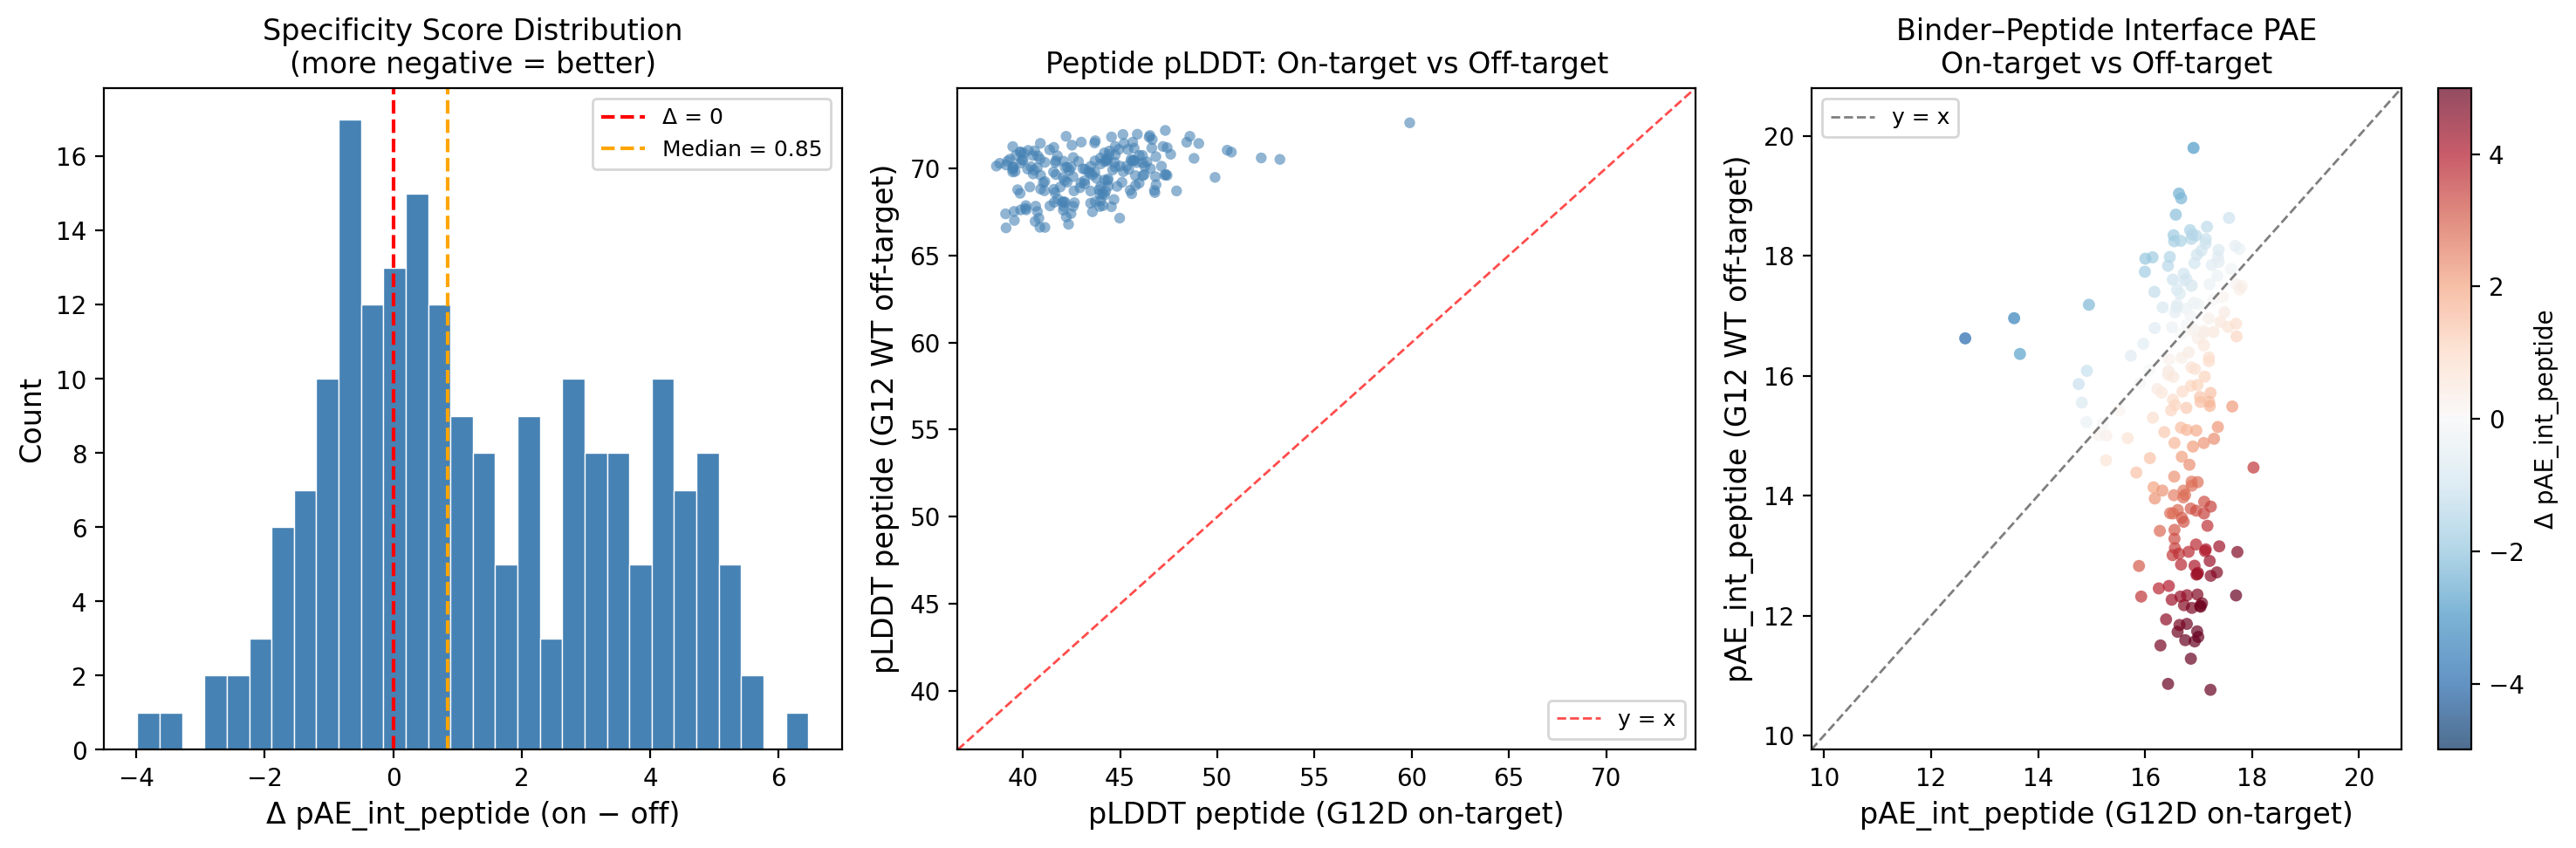

Violin plot saved to ~/Desktop/pmhc_binder_kras/specificity/pMHC_fold/outputs/r2/analysis/plddt_peptide_violin.png


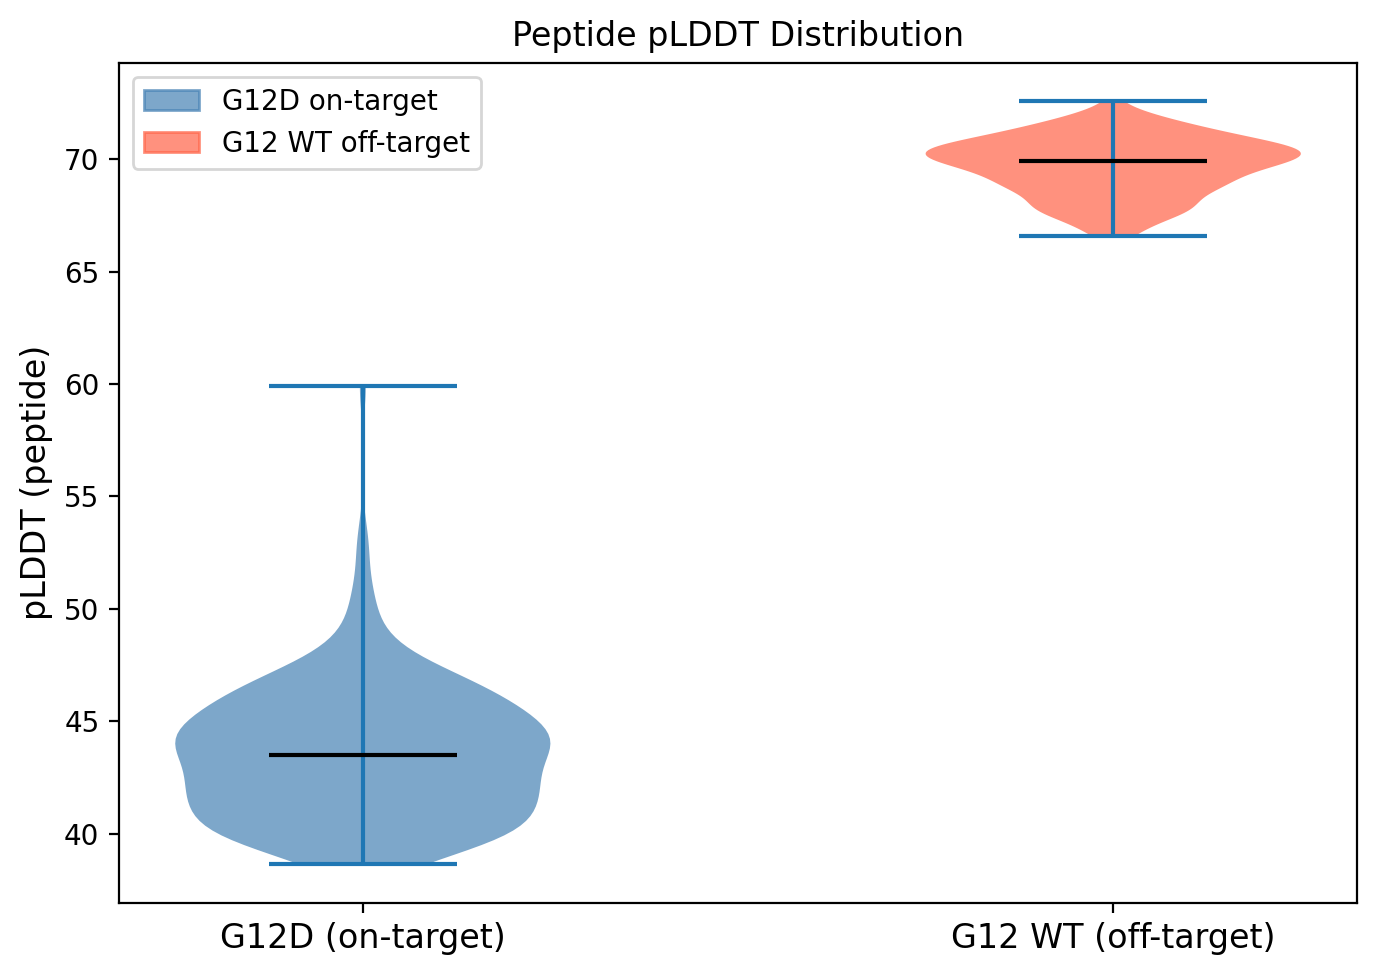


Done.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Δ pAE_int_peptide distribution
ax = axes[0]
ax.hist(merged['delta_pae_int_peptide'], bins=30, color='steelblue',
        edgecolor='white', linewidth=0.5)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Δ = 0')
ax.axvline(merged['delta_pae_int_peptide'].median(), color='orange',
           linestyle='--', linewidth=1.5,
           label=f"Median = {merged['delta_pae_int_peptide'].median():.2f}")
ax.set_xlabel('Δ pAE_int_peptide (on − off)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Specificity Score Distribution\n(more negative = better)', fontsize=12)
ax.legend(fontsize=9)

# Panel 2: pLDDT peptide on-target vs off-target
ax = axes[1]
ax.scatter(merged['plddt_peptide_on'], merged['plddt_peptide_off'],
           alpha=0.6, s=20, color='steelblue', edgecolors='none')
lims = [
    min(merged['plddt_peptide_on'].min(), merged['plddt_peptide_off'].min()) - 2,
    max(merged['plddt_peptide_on'].max(), merged['plddt_peptide_off'].max()) + 2
]
ax.plot(lims, lims, 'r--', linewidth=1, alpha=0.7, label='y = x')
ax.set_xlabel('pLDDT peptide (G12D on-target)', fontsize=12)
ax.set_ylabel('pLDDT peptide (G12 WT off-target)', fontsize=12)
ax.set_title('Peptide pLDDT: On-target vs Off-target', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(lims)
ax.set_ylim(lims)

# Panel 3: pAE_int_peptide on-target vs off-target, colored by Δ
ax = axes[2]
sc = ax.scatter(
    merged['ppi_pae_int_peptide_on'],
    merged['ppi_pae_int_peptide_off'],
    c=merged['delta_pae_int_peptide'],
    cmap='RdBu_r',
    vmin=-5, vmax=5,
    alpha=0.7, s=25, edgecolors='none'
)
lims2 = [
    min(merged['ppi_pae_int_peptide_on'].min(),
        merged['ppi_pae_int_peptide_off'].min()) - 1,
    max(merged['ppi_pae_int_peptide_on'].max(),
        merged['ppi_pae_int_peptide_off'].max()) + 1
]
ax.plot(lims2, lims2, 'k--', linewidth=1, alpha=0.5, label='y = x')
plt.colorbar(sc, ax=ax, label='Δ pAE_int_peptide')
ax.set_xlabel('pAE_int_peptide (G12D on-target)', fontsize=12)
ax.set_ylabel('pAE_int_peptide (G12 WT off-target)', fontsize=12)
ax.set_title('Binder–Peptide Interface PAE\nOn-target vs Off-target', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(lims2)
ax.set_ylim(lims2)

plt.tight_layout()
# fig.savefig(os.path.join(OUT_DIR, 'pmhc_fold_specificity.png'), dpi=150,
#             bbox_inches='tight')
print(f"Figure saved to {OUT_DIR}/pmhc_fold_specificity.png")
plt.show()

# ── pLDDT violin plot ─────────────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(7, 5))

data_to_plot = [
    merged['plddt_peptide_on'].values,
    merged['plddt_peptide_off'].values
]
parts = ax.violinplot(data_to_plot, positions=[1, 2], showmedians=True,
                      showextrema=True)

for pc in parts['bodies']:
    pc.set_alpha(0.7)
parts['bodies'][0].set_facecolor('steelblue')
parts['bodies'][1].set_facecolor('tomato')
parts['cmedians'].set_color('black')

ax.set_xticks([1, 2])
ax.set_xticklabels(['G12D (on-target)', 'G12 WT (off-target)'], fontsize=12)
ax.set_ylabel('pLDDT (peptide)', fontsize=12)
ax.set_title('Peptide pLDDT Distribution', fontsize=12)

blue_patch = mpatches.Patch(color='steelblue', alpha=0.7, label='G12D on-target')
red_patch  = mpatches.Patch(color='tomato',    alpha=0.7, label='G12 WT off-target')
ax.legend(handles=[blue_patch, red_patch], fontsize=10)

plt.tight_layout()
# fig2.savefig(os.path.join(OUT_DIR, 'plddt_peptide_violin.png'), dpi=150,
#              bbox_inches='tight')
print(f"Violin plot saved to {OUT_DIR}/plddt_peptide_violin.png")
plt.show()

print("\nDone.")